<a href="https://colab.research.google.com/github/pointernullbrain/Shark-Attacks-Analysis/blob/main/shark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import HeatMap

from scipy.stats import skew, kurtosis

import plotly.express as px
import os
import plotly.io as pio

In [ ]:
#Loading the dataset
path = "/content/drive/MyDrive/attacks/GSAF5.xls"
df = pd.read_excel(path)

display(df.head())

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,24th May,2026.0,Unprovoked,Australia,Queensland,Kennedy Shoal,Spearfishing,Michael Jensz,M,39,...,Undetermined Bull shark most likely,Simon de Marchi: 9 News: 7 News: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17th May,2026.0,Questionable,USA,Maryland,Assateague State Park,Surfing,Brendan Oster,M,?,...,Blue fish bite most probable,Keithe Cowley: Delmarva Now:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,16th May,2026.0,Unprovoked,Australia,Western Australia,Horseshoe Reef Rottnest Island,Skindiving,Steven Mattaboni,M,38,...,Great White Shark,ABC News: 9 News: 7 News: Simon De Marchi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,14th April,2026.0,UNprovoked,Maldives,Gaafu Alif Atoll,Kooddoo,Swimming,Not stated - on honeymoon,M,?,...,Unknown,The U.S. Sun: Simon De Marchi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3rd April,2026.0,Unprovoked,Australia,South Australia,Middleton Beach Fleurieu Peninsula Adelaide,Surfing,Oliver Tokic-Bensley,M,16,...,Bronze Whaler,ABC News: The Guardian: Andrew Currie and Bob...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Preprocessing and Exploration
  - check and remove missing values
  - filter for 2000 to 2025
  - remove questionable entries for type column
  - create is_fatal column with 1 for fatal, 0 for non fatal to count fatalities

In [ ]:
#Remove NA from year column
df = df[['Year', 'Type', 'Country', 'Activity', 'Fatal Y/N', 'Date']].dropna(subset=['Year'])

#Filter for year 2000 to 2026, filter out questionable entries
df = df[(df['Year'] >= 2000) & (df['Year'] < 2026)]
df = df[df['Type'].str.upper() != 'QUESTIONABLE']

print(f"Dataset Shape (Year 2000-2025, excluding Questionable): {df.shape}")
display(df.head())

#Clean the Fatal column, this is for later analysis
#Map 1 for fatal, 0 for non-fatal
df['Is_Fatal'] = df['Fatal Y/N'].str.upper().map({'Y': 1, 'N': 0})
df = df.dropna(subset=['Is_Fatal'])


#display(df['Is_Fatal'].value_counts(normalize=True))

Dataset Shape (Year 2000-2025, excluding Questionable): (2785, 6)


,Year,Type,Country,Activity,Fatal Y/N,Date
26,2025.0,Unprovoked,Mozambique,Not stated,Y,25th December
27,2025.0,Unprovoked,Australia,SCUBA Diving,N,21st December
28,2025.0,Unprovoked,USA,Swimming,Y,21st December
29,2025.0,Unprovoked,USA,Surfing,N,12th December
30,2025.0,Provoked,USA,Freeing trapped shark,N,9th December


Summary of Fatal vs Non-Fatal Attacks:


,proportion
Is_Fatal,
0.0,0.90027
1.0,0.09973


### 1. Detailed Descriptive Statistics (2000-2025)
  - get descriptive statistics for attacks per year

In [ ]:
#Calculate Attacks per Year and per Region
attacks_per_year = df.groupby('Year').size().rename('Attack_Count')
print(attacks_per_year.describe().to_frame().T)

#print(attacks_per_year) #Get numerical data of attacks per year



              count       mean        std   min   25%   50%    75%    max
Attack_Count   26.0  99.884615  18.300441  50.0  91.0  99.5  113.0  130.0


### 2. Global Shark Attacks per Year
  - trend of shark attacks per year

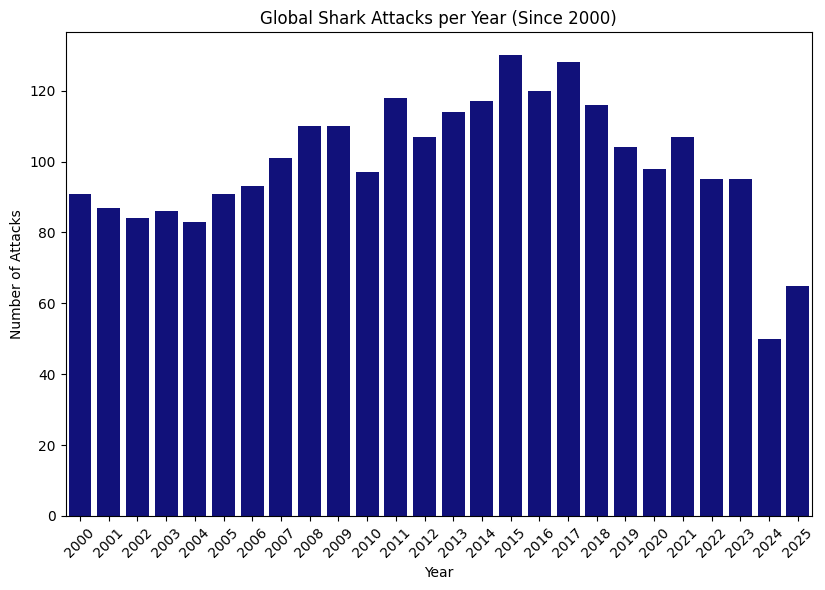

In [ ]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)

#Convert year to integer. if dont include this, then year will be float
year_counts = df['Year'].astype(int).value_counts().sort_index()

sns.barplot(x=year_counts.index, y=year_counts.values, color='darkblue')

plt.title('Global Shark Attacks per Year (Since 2000)')
plt.xticks(rotation=45)
plt.ylabel('Number of Attacks')
plt.tight_layout()
plt.show()

### 3. Distribution of Shark Attacks
  - plot histogram, and line plot
  - calculate and display skew and kurtosis


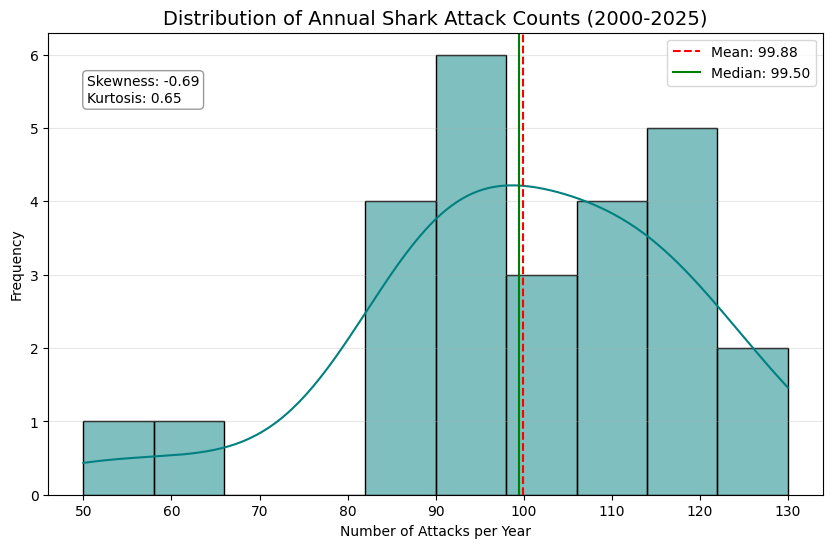

Distribution Statistics:
Skewness: -0.6904 (Values near 0 indicate symmetry)
Kurtosis: 0.6485 (Values near 0 indicate a normal distribution)


In [ ]:

#Get annual data
annual_data = df['Year'].astype(int).value_counts().sort_index()

#Calculate skew and kurtosis
data_skew = skew(annual_data)
data_kurt = kurtosis(annual_data)

#Visualization
plt.figure(figsize=(10, 6))
sns.histplot(annual_data, kde=True, color='teal', bins=10)

#Add statistical annotations to the plot
plt.axvline(annual_data.mean(), color='red', linestyle='--', label=f'Mean: {annual_data.mean():.2f}')
plt.axvline(annual_data.median(), color='green', linestyle='-', label=f'Median: {annual_data.median():.2f}')

plt.title('Distribution of Annual Shark Attack Counts (2000-2025)', fontsize=14)
plt.xlabel('Number of Attacks per Year')
plt.ylabel('Frequency')

#Display Skewness and Kurtosis text
stats_text = f'Skewness: {data_skew:.2f}\nKurtosis: {data_kurt:.2f}'
plt.annotate(stats_text, xy=(0.05, 0.85), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### 4. Activity Analysis
  - analyse top 10 activities reported during shark attacks
  - compare the proportion of fatal vs non-fatal attacks for each

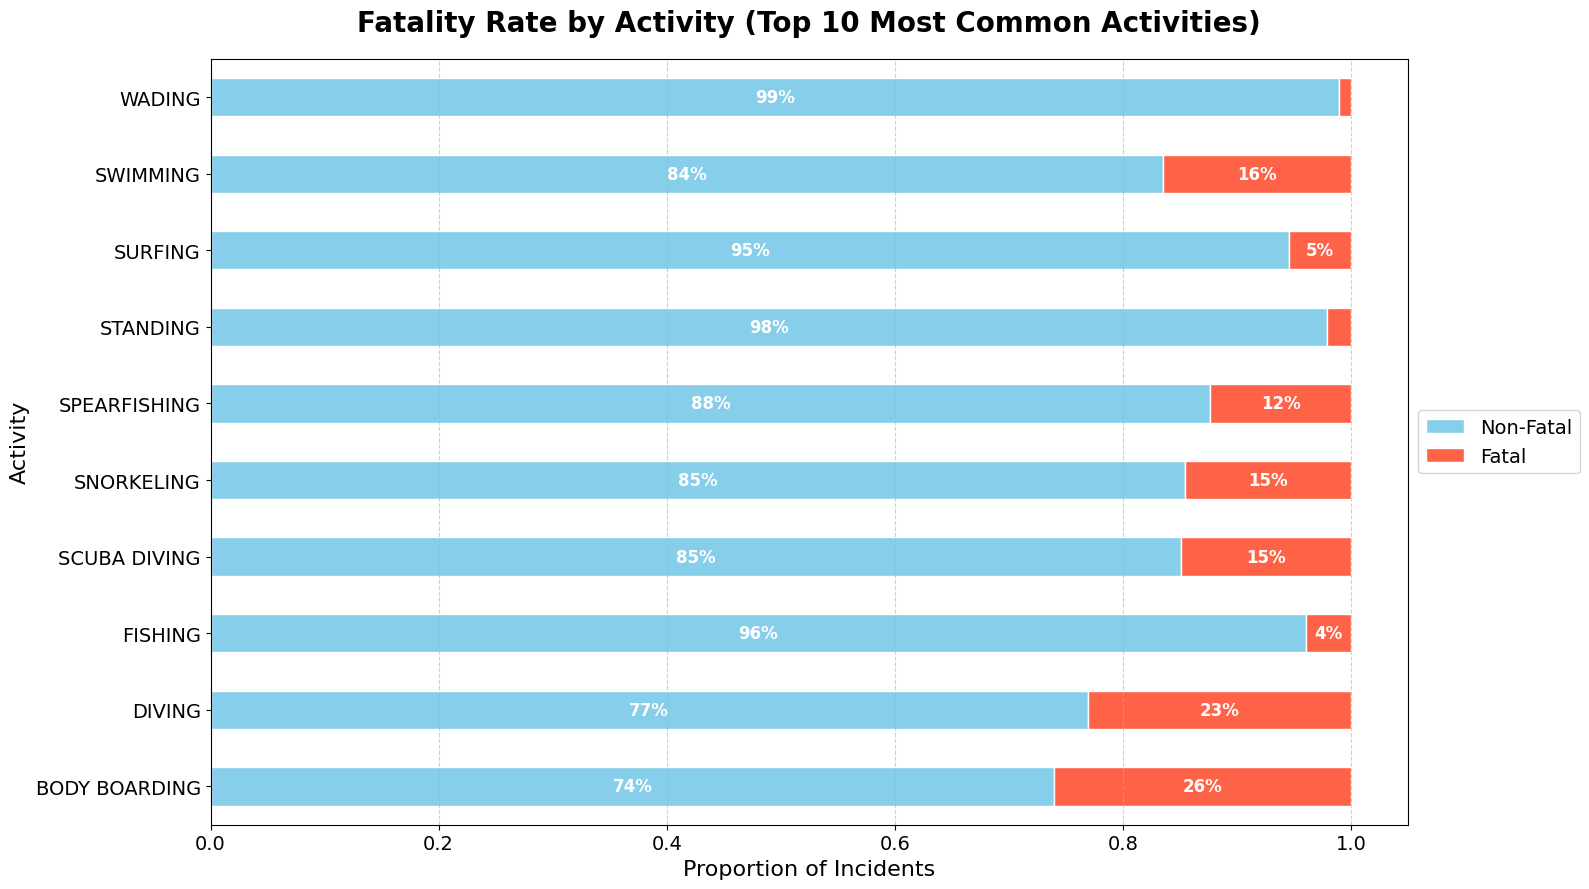

In [ ]:
#Clean the Activity column: handle NaNs, convert to upper, and strip whitespace
df['Activity_Clean'] = df['Activity'].dropna().str.upper().str.strip()

#Identify the top 10 activities by frequency
top_activities = df['Activity_Clean'].value_counts().nlargest(10).index
df_top_act = df[df['Activity_Clean'].isin(top_activities)].copy()

#Create a pivot table to show the ratio of Fatal vs Non-Fatal
#0 = Non-Fatal, 1 = Fatal
activity_pivot = pd.crosstab(df_top_act['Activity_Clean'], df_top_act['Is_Fatal'], normalize='index')

#Visualization optimized for reports
#Using a standard 16:9 ratio but large enough for high DPI
ax = activity_pivot.plot(kind='barh',
                         stacked=True,
                         figsize=(16, 9),
                         color=['#87CEEB', '#FF6347'],
                         edgecolor='white')

#Increase title and label sizes for report quality
plt.title('Fatality Rate by Activity (Top 10 Most Common Activities)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Proportion of Incidents', fontsize=16)
plt.ylabel('Activity', fontsize=16)

#Move legend outside to the right and increase font size
plt.legend(['Non-Fatal', 'Fatal'], loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14, frameon=True)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=14)

#Add percentage labels with larger font
for p in ax.patches:
    width = p.get_width()
    if width > 0.03: # Label if bar is wide enough to see
        ax.annotate(f'{width:.0%}',
                    (p.get_x() + width/2, p.get_y() + p.get_height()/2),
                    ha='center', va='center',
                    color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

### 5. Fatality Rate by Country
  - calculate percentage of fatal attacks for 10 countries with most incidents

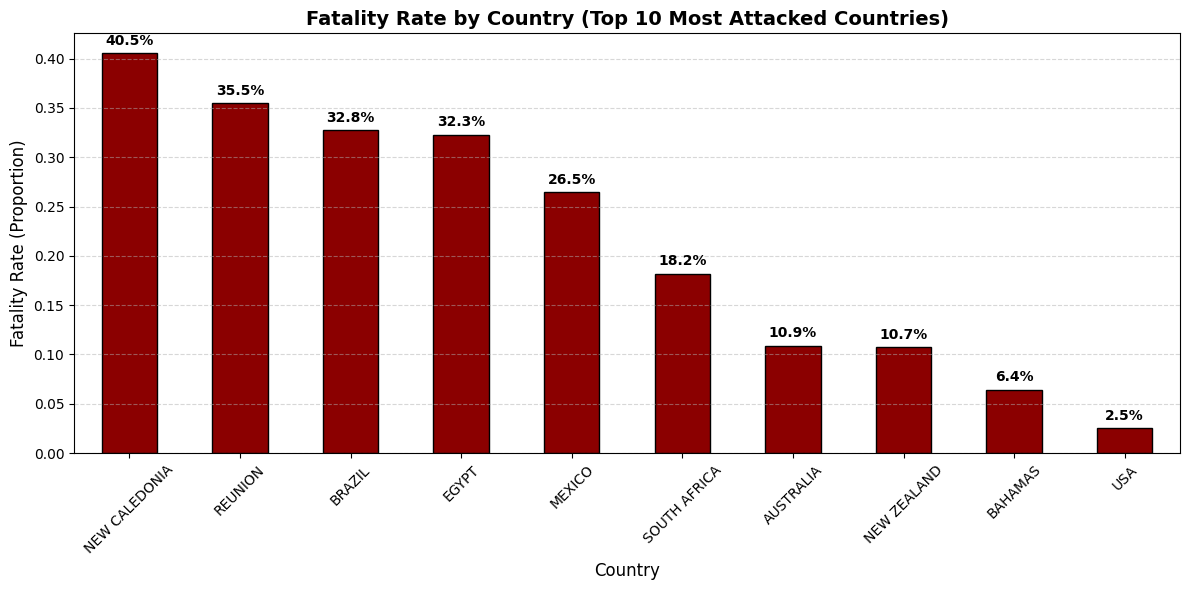

In [ ]:
#Identify top 10 countries by attack count from our filtered dataframe
top_countries = df['Country'].str.strip().str.upper().value_counts().nlargest(10).index
df_top_countries = df[df['Country'].str.strip().str.upper().isin(top_countries)].copy()

#Calculate fatality rate (mean of Is_Fatal which is 0 or 1)
country_fatality = df_top_countries.groupby(df_top_countries['Country'].str.strip().str.upper())['Is_Fatal'].mean().sort_values(ascending=False)

#Visualization
plt.figure(figsize=(12, 6))
ax = country_fatality.plot(kind='bar', color='#8B0000', edgecolor='black')

plt.title('Fatality Rate by Country (Top 10 Most Attacked Countries)', fontsize=14, fontweight='bold')
plt.ylabel('Fatality Rate (Proportion)', fontsize=12)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

#Add labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 6. Species Analysis for Fatalities
  - analyze the `Species` column specifically for incidents where `Is_Fatal == 1`
  - perform some basic cleaning to extract common names like 'White shark' or 'Tiger shark'

/tmp/ipykernel_9502/3393710476.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=species_fatalities, x='Fatal_Count', y='Species', palette='Reds_r')


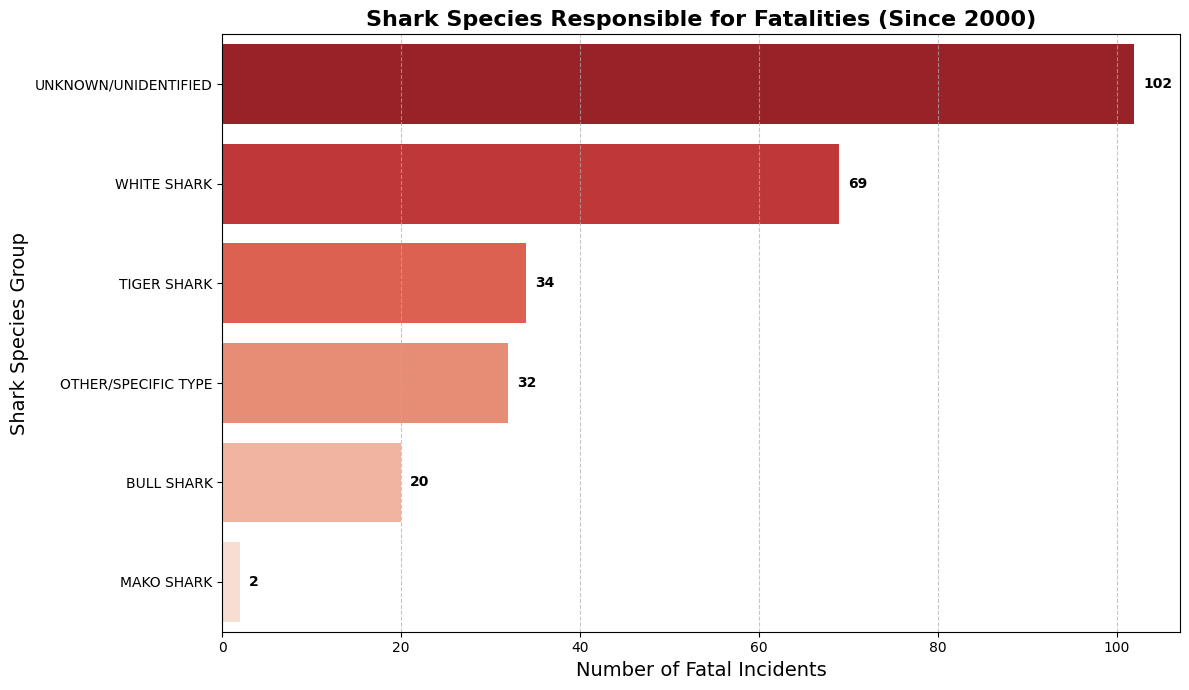

In [ ]:
#Create a subset of fatal incidents
fatal_df = df[df['Is_Fatal'] == 1].copy()

#Clean the Species column (basic cleaning to extract names)
#Convert to upper case and remove common non-species words/numbers
fatal_df['Species_Clean'] = fatal_df['Species '].fillna('UNKNOWN').str.upper()

#Mapping for common major species names often found in descriptive strings
def simplify_species(text):
    if 'WHITE' in text: return 'WHITE SHARK'
    if 'TIGER' in text: return 'TIGER SHARK'
    if 'BULL' in text: return 'BULL SHARK'
    if 'WHALER' in text: return 'WHALER SHARK'
    if 'BLACKTIP' in text: return 'BLACKTIP SHARK'
    if 'MAKO' in text: return 'MAKO SHARK'
    if 'HAMMERHEAD' in text: return 'HAMMERHEAD SHARK'
    if 'UNKNOWN' in text or 'NOT IDENTIFIED' in text: return 'UNKNOWN/UNIDENTIFIED'
    return 'OTHER/SPECIFIC TYPE'

fatal_df['Species_Grouped'] = fatal_df['Species_Clean'].apply(simplify_species)

#Aggregate counts
species_fatalities = fatal_df['Species_Grouped'].value_counts().reset_index()
species_fatalities.columns = ['Species', 'Fatal_Count']

#Visualization
plt.figure(figsize=(12, 7))
sns.barplot(data=species_fatalities, x='Fatal_Count', y='Species', palette='Reds_r')
plt.title('Shark Species Responsible for Fatalities (Since 2000)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Fatal Incidents', fontsize=14)
plt.ylabel('Shark Species Group', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

#Add count labels
for i, count in enumerate(species_fatalities['Fatal_Count']):
    plt.text(count + 1, i, str(count), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 7. Modern Seasonality Analysis (Year 2000+)
  - combines geography and timing to show which months are most active for shark attacks in different countries, focusing on data from the year 2000 onwards.

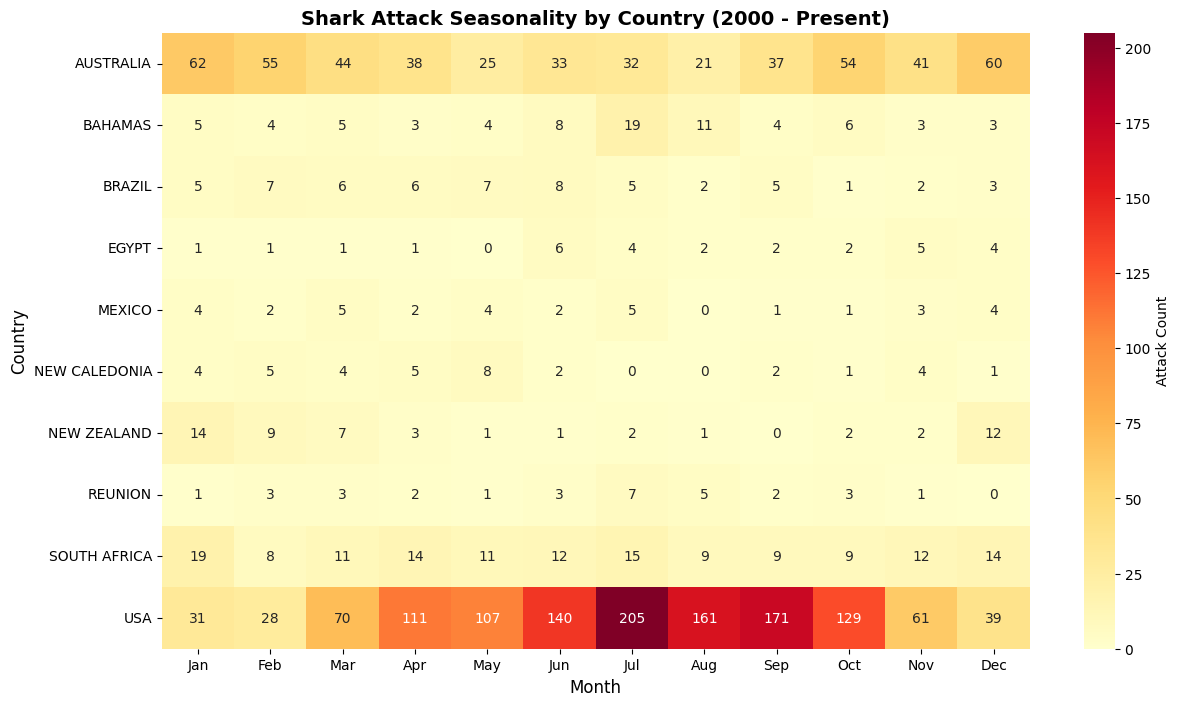

In [ ]:
#Define helper to extract month
months_list = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
def get_month(date_str):
    if isinstance(date_str, str):
        for m in months_list:
            if m in date_str:
                return m
    return None

#Copy dataframe which contains dates, convert to string and apply helper function
seasonal_data = df.copy()
seasonal_data['Month'] = seasonal_data['Date'].astype(str).apply(get_month)

#Focus on top 10 countries
top_10_countries = seasonal_data['Country'].str.strip().str.upper().value_counts().nlargest(10).index
seasonal_data = seasonal_data[seasonal_data['Country'].str.strip().str.upper().isin(top_10_countries)]

#Create Pivot and Visualize
pivot_table = pd.crosstab(seasonal_data['Country'].str.strip().str.upper(), seasonal_data['Month'])
pivot_table = pivot_table.reindex(columns=months_list).fillna(0)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Attack Count'})
plt.title('Shark Attack Seasonality by Country (2000 - Present)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()

### 8. Plotly Density Heatmap
  - Plotly provides a more robust way to export static images using the `kaleido` engine

In [ ]:
#!pip install -q plotly kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 6.8 MB/s eta 0:00:00


In [ ]:
#Include all countries found in the dataset
#Using approximate central coordinates for major regions
geo_map = {
    'USA': [37.0902, -95.7129],
    'AUSTRALIA': [-25.2744, 133.7751],
    'SOUTH AFRICA': [-30.5595, 22.9375],
    'BAHAMAS': [25.0343, -77.3963],
    'BRAZIL': [-14.2350, -51.9253],
    'NEW ZEALAND': [-40.9006, 174.8860],
    'REUNION': [-21.1151, 55.5364],
    'MEXICO': [23.6345, -102.5528],
    'BRAZIL': [-14.2350, -51.9253],
    'ECUADOR': [-1.8312, -78.1834],
    'COLOMBIA': [4.5709, -74.2973],
    'NEW CALEDONIA': [-20.9043, 165.6180],
    'EGYPT': [26.8206, 30.8025],
    'SPAIN': [40.4637, -3.7492],
    'FIJI': [-17.7134, 178.0650]
}

plot_data = []
current_countries = df['Country'].str.strip().str.upper().unique()

for country in current_countries:
    if country in geo_map:
        coords = geo_map[country]
        count = df[df['Country'].str.strip().str.upper() == country].shape[0]
        plot_data.append([country, coords[0], coords[1], count])

plot_df = pd.DataFrame(plot_data, columns=['country', 'lat', 'lon', 'attacks'])

#Create the Map
fig = px.density_mapbox(plot_df,
                        lat='lat',
                        lon='lon',
                        z='attacks',
                        hover_name='country',
                        radius=40,
                        center=dict(lat=10, lon=0),
                        zoom=1,
                        mapbox_style="carto-positron",
                        title='Global Shark Attack Density (2000-2025, Non-Questionable)')

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

### 9. Fatality Breakdown by Type (Provoked vs. Unprovoked)
  - filter the fatal incidents to compare the counts between Provoked and Unprovoked types.

/tmp/ipykernel_9502/4048690729.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




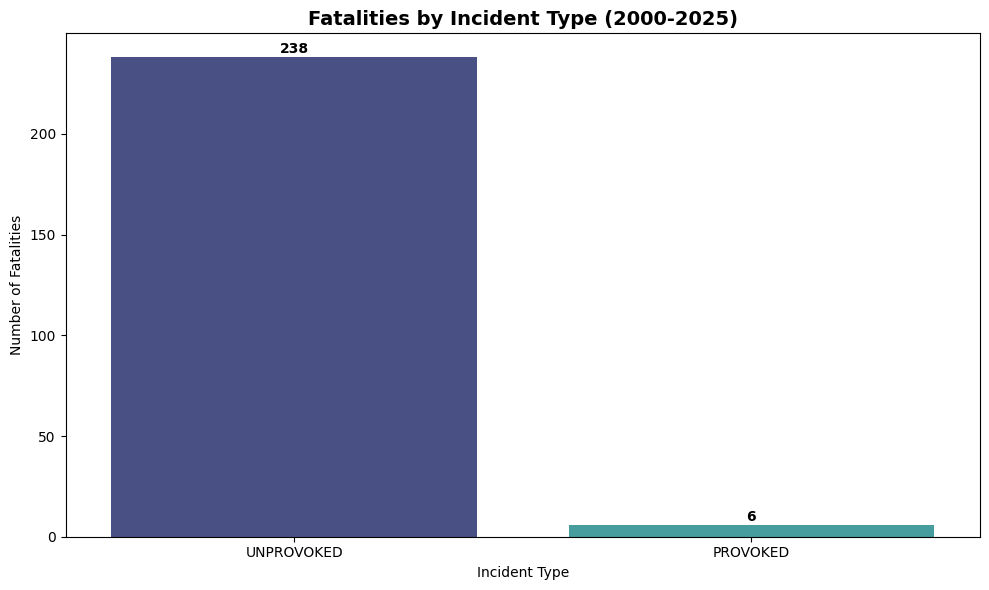

In [ ]:
#Simplify the 'Type' column
fatal_type_df = fatal_df
fatal_type_df['Type_Simple'] = fatal_type_df['Type'].str.upper().str.strip()

#Keep only Provoked and Unprovoked
fatal_type_counts = fatal_type_df[fatal_type_df['Type_Simple'].isin(['PROVOKED', 'UNPROVOKED'])]['Type_Simple'].value_counts()

#Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=fatal_type_counts.index, y=fatal_type_counts.values, palette='mako')

plt.title('Fatalities by Incident Type (2000-2025)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Fatalities')
plt.xlabel('Incident Type')

#Add labels on top of bars
for i, count in enumerate(fatal_type_counts.values):
    plt.text(i, count + 2, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()